# TASK 4: Sentiment Analysis

In [27]:
#Goal: Classify text reviews as Positive, Negative, or Neutral using VADER NLP.
#Tools: `nltk` (VADER), `matplotlib`, `wordcloud`

In [34]:
import pandas as pd                     # Data manipulation and analysis
import numpy as np                      # Numerical operations
import matplotlib.pyplot as plt         # Data visualization
import matplotlib.patches as mpatches   # Custom legend patches for plots
from nltk.sentiment.vader import SentimentIntensityAnalyzer  # Sentiment analysis tool

# Sample review dataset: (Review text, Product category, Star rating)
reviews_data = [
    ("This book completely changed my perspective on life. Absolutely brilliant!",    "Books",       5),
    ("Amazing read! I couldn't put it down. Highly recommend to everyone.",           "Books",       5),
    ("Fantastic storytelling, vivid characters, and a thrilling plot. Loved it!",    "Books",       5),
    ("Wonderful experience. Very well written and deeply insightful.",                "Electronics", 5),
    ("Great product! Exceeded my expectations. Will definitely buy again.",           "Electronics", 5),
    ("Excellent quality! Fast delivery and item is even better than described.",      "Clothing",    5),
    ("Super happy with this purchase. Five stars without hesitation!",                "Clothing",    5),
    ("Loved every feature of this. The company's best product yet.",                 "Electronics", 5),
    ("Outstanding! Works perfectly right out of the box. Very impressed.",            "Electronics", 4),
    ("Beautiful design and excellent build quality. Totally worth the price!",        "Clothing",    4),
    ("Terrible. Boring story, flat characters. Complete waste of money.",             "Books",       1),
    ("Extremely disappointed. The product made no sense at all.",                     "Electronics", 1),
    ("Awful quality. I regret buying it. Stopped using after one week.",              "Clothing",    1),
    ("Very poor. Fell apart in two days. Would not recommend to anyone.",             "Clothing",    1),
    ("Horrible experience. Customer service was useless too. Never again!",           "Electronics", 1),
    ("Worst purchase I've made this year. Total garbage. Avoid at all costs!",        "Books",       1),
    ("Defective product. Arrived damaged. Impossible to get a refund.",               "Electronics", 2),
    ("Terrible smell, wrong size, and terrible stitching. Deeply dissatisfied.",     "Clothing",    2),
    ("The product arrived on time. It is what it is. Average quality.",               "Books",       3),
    ("It's okay. Some parts are useful, others are quite unnecessary.",               "Electronics", 3),
    ("Not bad, not great. The design is predictable but functional.",                "Clothing",    3),
    ("Decent overall. Probably better suited for a different use case.",              "Books",       3),
    ("Standard quality. Nothing special but does the job adequately.",               "Electronics", 3),
    ("An average experience. The product covers the basics but lacks depth.",        "Clothing",    3),
]

# Convert the raw review data into a structured pandas DataFrame
df_reviews = pd.DataFrame(reviews_data, columns=['Review','Category','Stars'])

# Print basic dataset summary: total reviews and number of unique categories
print(f"Loaded {len(df_reviews)} reviews across {df_reviews['Category'].nunique()} categories")

# Display the first few rows of the DataFrame for quick inspection
df_reviews.head()

Loaded 24 reviews across 3 categories


,Review,Category,Stars
0,This book completely changed my perspective on...,Books,5
1,Amazing read! I couldn't put it down. Highly r...,Books,5
2,"Fantastic storytelling, vivid characters, and ...",Books,5
3,Wonderful experience. Very well written and de...,Electronics,5
4,Great product! Exceeded my expectations. Will ...,Electronics,5


In [35]:
sia = SentimentIntensityAnalyzer()   # Initialize VADER sentiment analyzer

def analyze_sentiment(text):
    scores   = sia.polarity_scores(text)   # Get sentiment scores for the review text
    compound = scores['compound']          # Extract overall (compound) sentiment score

    # Assign sentiment label based on VADER compound score thresholds
    label = 'Positive' if compound >= 0.05 else ('Negative' if compound <= -0.05 else 'Neutral')

    # Return sentiment scores and label as a pandas Series
    return pd.Series({
        'Pos_Score': round(scores['pos'], 3),   # Positive sentiment score
        'Neg_Score': round(scores['neg'], 3),   # Negative sentiment score
        'Neu_Score': round(scores['neu'], 3),   # Neutral sentiment score
        'Compound' : round(compound, 4),        # Overall sentiment score
        'Sentiment': label                      # Final sentiment classification
    })

# Apply sentiment analysis to each review in the dataset
sentiment_df = df_reviews['Review'].apply(analyze_sentiment)

# Combine original review data with sentiment analysis results
df_results   = pd.concat([df_reviews, sentiment_df], axis=1)

# Display key sentiment results for each review
print("Sentiment Analysis Results:")
print(df_results[['Review','Compound','Sentiment']].to_string(index=False))

Sentiment Analysis Results:
                                                                    Review  Compound Sentiment
This book completely changed my perspective on life. Absolutely brilliant!    0.6581  Positive
       Amazing read! I couldn't put it down. Highly recommend to everyone.    0.7836  Positive
 Fantastic storytelling, vivid characters, and a thrilling plot. Loved it!    0.8977  Positive
            Wonderful experience. Very well written and deeply insightful.    0.7264  Positive
       Great product! Exceeded my expectations. Will definitely buy again.    0.7959  Positive
  Excellent quality! Fast delivery and item is even better than described.    0.7840  Positive
            Super happy with this purchase. Five stars without hesitation!    0.8660  Positive
              Loved every feature of this. The company's best product yet.    0.8442  Positive
        Outstanding! Works perfectly right out of the box. Very impressed.    0.9167  Positive
    Beautiful design a

In [36]:
print("Overall Sentiment Distribution:")
dist = df_results['Sentiment'].value_counts()   # Count occurrences of each sentiment label

for sent, count in dist.items():
    pct = count / len(df_results) * 100         # Calculate percentage share of each sentiment
    bar = '|' * int(pct / 3)                    # Simple text-based bar for visual emphasis
    print(f"  {sent:<12}: {bar} {count} ({pct:.1f}%)")

print("\nPer-Category Sentiment:")
# Cross-tabulation showing sentiment distribution within each product category
print(pd.crosstab(df_results['Category'], df_results['Sentiment']))

print(f"\nAverage Compound Score: {df_results['Compound'].mean():.4f}")  # Overall sentiment average

# Identify the most positive review based on highest compound score
print(f"Most positive: {df_results.loc[df_results['Compound'].idxmax(),'Review'][:70]}")

# Identify the most negative review based on lowest compound score
print(f"Most negative: {df_results.loc[df_results['Compound'].idxmin(),'Review'][:70]}")

Overall Sentiment Distribution:
  Positive    : |||||||||||||||||| 13 (54.2%)
  Negative    : |||||||||||| 9 (37.5%)
  Neutral     : || 2 (8.3%)

Per-Category Sentiment:
Sentiment    Negative  Neutral  Positive
Category                                
Books               2        1         4
Clothing            3        1         4
Electronics         4        0         5

Average Compound Score: 0.1406
Most positive: Outstanding! Works perfectly right out of the box. Very impressed.
Most negative: Terrible smell, wrong size, and terrible stitching. Deeply dissatisfie


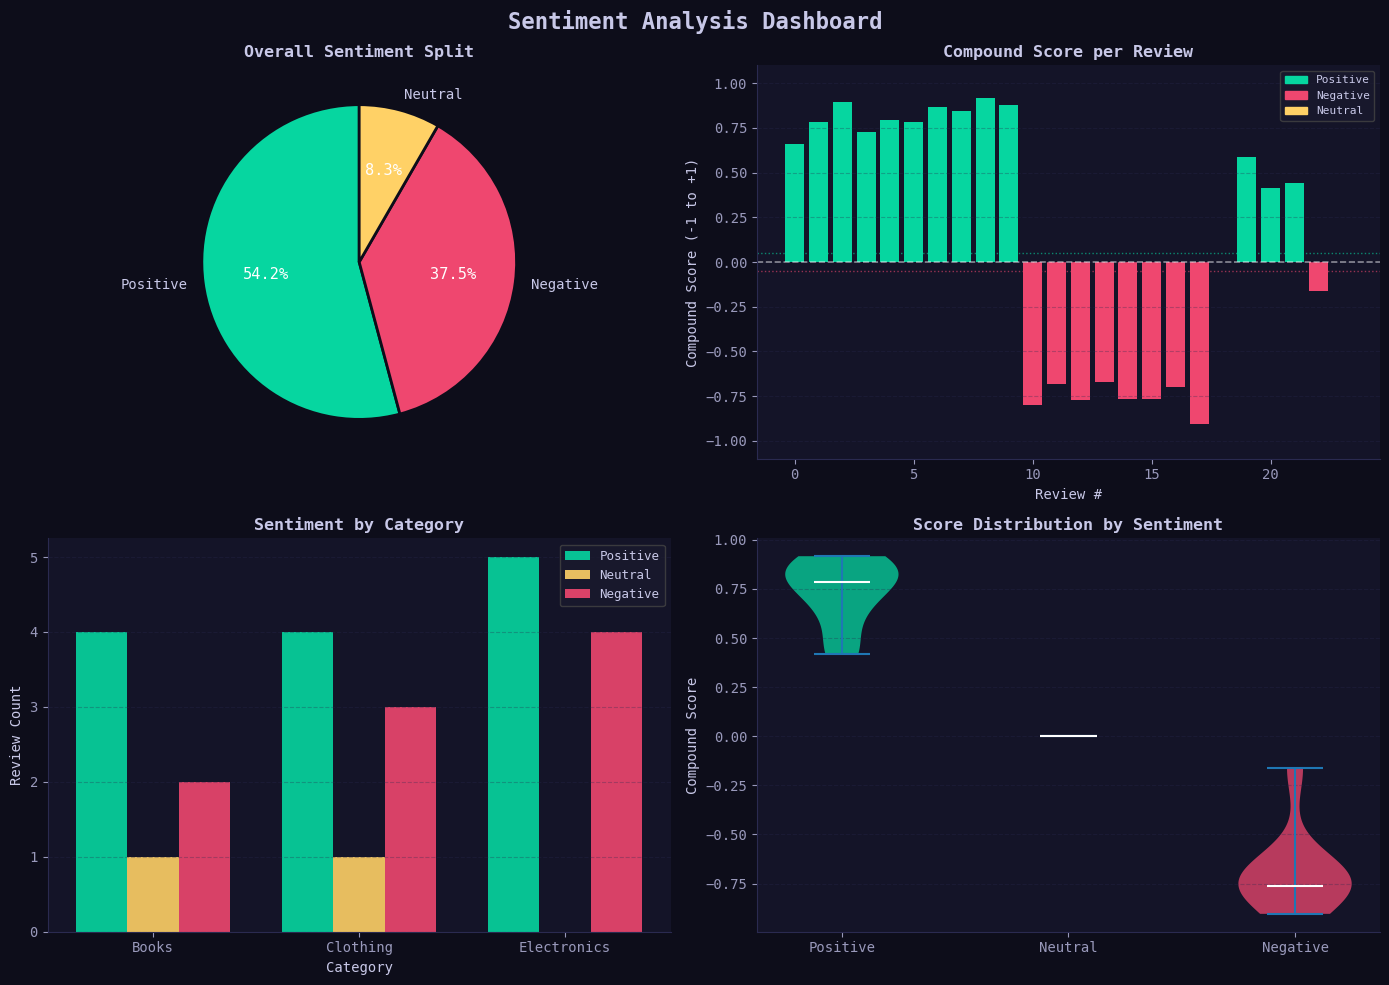

Chart 6 saved: chart6_sentiment_dashboard.png


In [37]:
# Sentiment Dashboard
SENT_COLORS = {'Positive': '#06d6a0', 'Negative': '#ef476f', 'Neutral': '#ffd166'}  # Color mapping for sentiments

# Create a 2x2 dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sentiment Analysis Dashboard", fontsize=16, fontweight='bold', y=0.98)

# -------------------------
# Panel A: Pie Chart – Overall Sentiment Split
# -------------------------
ax = axes[0, 0]  # Select top-left subplot
counts = df_results['Sentiment'].value_counts()  # Count sentiment labels
colors = [SENT_COLORS.get(s, '#aaa') for s in counts.index]  # Map colors to sentiments

# Draw pie chart
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0d0d1a', linewidth=2)
)

# Style percentage labels
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(11)

ax.set_title("Overall Sentiment Split", fontsize=12, fontweight='bold')

# -------------------------
# Panel B: Bar Chart – Compound Score per Review
# -------------------------
ax = axes[0, 1]  # Select top-right subplot
bar_colors = [SENT_COLORS.get(s, '#aaa') for s in df_results['Sentiment']]  # Color bars by sentiment

# Plot compound sentiment score for each review
ax.bar(range(len(df_results)), df_results['Compound'], color=bar_colors, edgecolor='none')

# Reference lines for sentiment thresholds
ax.axhline(0,     color='white',   lw=1.2, ls='--', alpha=0.5)   # Neutral line
ax.axhline(0.05,  color='#06d6a0', lw=1,   ls=':',  alpha=0.6)   # Positive threshold
ax.axhline(-0.05, color='#ef476f', lw=1,   ls=':',  alpha=0.6)   # Negative threshold

# Axis labels and formatting
ax.set_title("Compound Score per Review", fontsize=12, fontweight='bold')
ax.set_xlabel("Review #")
ax.set_ylabel("Compound Score (-1 to +1)")
ax.set_ylim(-1.1, 1.1)
ax.grid(axis='y', alpha=0.3)

# Custom legend for sentiment colors
patches = [mpatches.Patch(color=v, label=k) for k, v in SENT_COLORS.items()]
ax.legend(handles=patches, facecolor='#1a1a2e', edgecolor='#444', fontsize=8)

# -------------------------
# Panel C: Grouped Bar Chart – Sentiment by Category
# -------------------------
ax = axes[1, 0]  # Select bottom-left subplot
cross = pd.crosstab(df_results['Category'], df_results['Sentiment'])  # Category vs sentiment table

# Ensure all sentiment columns exist
for col in ['Positive','Neutral','Negative']:
    if col not in cross.columns:
        cross[col] = 0

# Reorder columns
cross = cross[['Positive','Neutral','Negative']]

# Bar positions
x = np.arange(len(cross))
w = 0.25  # Bar width

# Plot grouped bars
for i, (col, color) in enumerate(zip(cross.columns, ['#06d6a0','#ffd166','#ef476f'])):
    ax.bar(x + (i-1)*w, cross[col], width=w, color=color, label=col, alpha=0.9)

# Axis labels and styling
ax.set_xticks(x)
ax.set_xticklabels(cross.index)
ax.set_title("Sentiment by Category", fontsize=12, fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Review Count")
ax.legend(facecolor='#1a1a2e', edgecolor='#444', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# -------------------------
# Panel D: Violin Plot – Compound Score Distribution by Sentiment
# -------------------------
ax = axes[1, 1]  # Select bottom-right subplot

# Prepare compound score groups per sentiment
g_data   = [df_results[df_results['Sentiment']==s]['Compound'].values for s in ['Positive','Neutral','Negative']]
g_labels = ['Positive','Neutral','Negative']
g_colors = ['#06d6a0','#ffd166','#ef476f']

# Remove empty sentiment groups
g_data   = [g for g in g_data if len(g) > 0]
g_labels = [l for l, g in zip(g_labels, [df_results[df_results['Sentiment']==s]['Compound'].values for s in ['Positive','Neutral','Negative']]) if len(g) > 0]
g_colors = g_colors[:len(g_data)]

# Plot violin plot if enough data exists, else fallback to bar plot
if len(g_data) >= 2:
    vp = ax.violinplot(g_data, showmedians=True)
    for body, color in zip(vp['bodies'], g_colors):
        body.set_facecolor(color)
        body.set_alpha(0.75)
    vp['cmedians'].set_color('white')
    ax.set_xticks(range(1, len(g_labels)+1))
    ax.set_xticklabels(g_labels)
else:
    ax.bar(g_labels, [len(g) for g in g_data], color=g_colors)

# Final styling
ax.set_title("Score Distribution by Sentiment", fontsize=12, fontweight='bold')
ax.set_ylabel("Compound Score")
ax.grid(axis='y', alpha=0.3)

# Save and display the dashboard
plt.tight_layout()
plt.savefig("chart6_sentiment_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved: chart6_sentiment_dashboard.png")

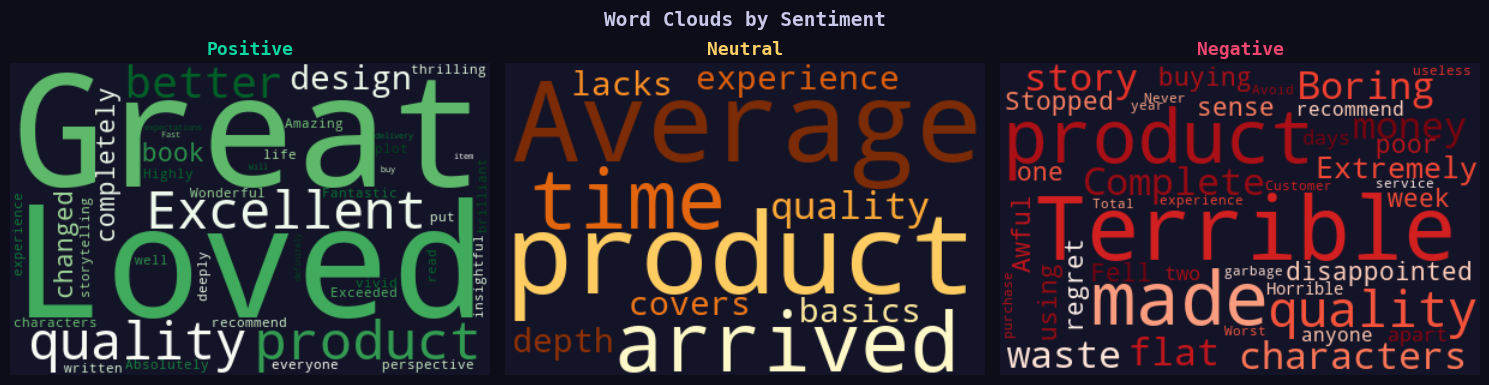

Chart 7 saved: chart7_wordclouds.png


In [38]:
# Word Clouds per Sentiment
try:
    from wordcloud import WordCloud   # Import WordCloud for text visualization

    # Create a row of 3 subplots (Positive, Neutral, Negative)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Word Clouds by Sentiment", fontsize=14, fontweight='bold')

    # Color map and title color settings for each sentiment
    wc_settings = {
        'Positive': ('Greens',  '#06d6a0'),   # Green theme for positive sentiment
        'Neutral':  ('YlOrBr',  '#ffd166'),   # Yellow/orange theme for neutral sentiment
        'Negative': ('Reds',    '#ef476f'),   # Red theme for negative sentiment
    }

    # Generate one word cloud per sentiment
    for ax, sentiment in zip(axes, ['Positive','Neutral','Negative']):
        # Combine all reviews of the given sentiment into a single text string
        text = " ".join(df_results[df_results['Sentiment'] == sentiment]['Review'])

        # Select colormap and title color
        cmap, title_color = wc_settings[sentiment]

        # Generate word cloud only if text is not empty
        if text.strip():
            wc = WordCloud(
                width=400,
                height=260,
                background_color='#141428',
                colormap=cmap,
                max_words=40
            ).generate(text)

            # Display the generated word cloud
            ax.imshow(wc, interpolation='bilinear')

        # Set subplot title and remove axes for clean look
        ax.set_title(sentiment, color=title_color, fontsize=13, fontweight='bold')
        ax.axis('off')

    # Adjust layout, save, and display the figure
    plt.tight_layout()
    plt.savefig("chart7_wordclouds.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart 7 saved: chart7_wordclouds.png")

except ImportError:
    # Fallback message if WordCloud library is not installed
    print("WordCloud not installed. Run: pip install wordcloud")

In [39]:
# Save the final sentiment analysis results to a CSV file
df_results.to_csv("sentiment_results.csv", index=False)
print("Saved: sentiment_results.csv")

# Print a visual separator for the final completion message
print("\n" + "=" * 60)

# Display completion banner for all analytics tasks
print("   ALL 4 DATA ANALYTICS TASKS COMPLETED!")
print("=" * 60)

# Summary of completed tasks and generated outputs
print("  Task 1 | Web Scraping       -> scraped_books.csv")        # Dataset from web scraping
print("  Task 2 | EDA                -> Stats, outliers, hypothesis test")  # Exploratory Data Analysis
print("  Task 3 | Data Visualization -> chart1 to chart5 .png files")       # Visualization outputs
print("  Task 4 | Sentiment Analysis -> sentiment_results.csv + chart6-7")  # Sentiment analysis results

# Final separator
print("=" * 60)

Saved: sentiment_results.csv

   ALL 4 DATA ANALYTICS TASKS COMPLETED!
  Task 1 | Web Scraping       -> scraped_books.csv
  Task 2 | EDA                -> Stats, outliers, hypothesis test
  Task 3 | Data Visualization -> chart1 to chart5 .png files
  Task 4 | Sentiment Analysis -> sentiment_results.csv + chart6-7
